<a href="https://colab.research.google.com/github/PriteshPurkar/NLP/blob/main/NLP_Text_preprocessing_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: Pritesh Pravin Purkar**

**PRN: 202301060010**

**Batch: T3**

##NLP Preprocessing and Text Classification

**Objective:**

**The objective of this assignment is to implement NLP preprocessing techniques and build a text classification model using machine learning techniques.**

**Dataset:** **NLTK Movie Reviews Corpus (2,000 labeled reviews).**

**Step 1: Data Preparation**

Description: Initialized the environment by installing transformers for deep learning and nltk/spacy for linguistic processing.

Key Action: Downloaded the movie_reviews dataset and the en_core_web_sm English model to handle tokenization and lemmatization

In [2]:
# 1. Install required libraries
!pip install nltk spacy scikit-learn transformers torch --quiet
!python -m spacy download en_core_web_sm --quiet

import nltk
import pandas as pd
import numpy as np
import spacy

# 2. Download ALL necessary NLTK resources at once
# This prevents the LookupError you just saw
nltk.download('movie_reviews')  # The dataset
nltk.download('punkt')          # For tokenization
nltk.download('stopwords')      # For filtering common words
nltk.download('wordnet')        # For lemmatization (if using NLTK lemmatizer)
nltk.download('omw-1.4')        # Support for wordnet

from nltk.corpus import movie_reviews
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from transformers import pipeline

print("✅ Step 1 Success: All packages and NLTK data are ready!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Step 1 Success: All packages and NLTK data are ready!


#Implementation of Preprocessing

**Techniques Used:** Tokenization, Stopword Removal, Stemming, and Lemmatization.

**Information:**

**Tokenization:** Breaking the reviews into individual words (tokens).

**Stopword Removal:** Filtering out common words like "the", "is", and "and" that do not contribute to sentiment.

**Lemmatization:** Reducing words to their dictionary root (e.g., "running" to "run") using spaCy to preserve context.

**Stemming:** Applying the Porter Stemmer to strip suffixes for a more aggressive reduction of word forms.

In [3]:
nlp = spacy.load("en_core_web_sm")
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

# 1. Load the Movie Reviews dataset
documents = [(' '.join(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

df = pd.DataFrame(documents, columns=['text', 'label'])

# 2. Comprehensive Preprocessing Function
def full_preprocess(text):
    # Tokenization and Lemmatization (spaCy)
    doc = nlp(text.lower())

    # Remove Stopwords and non-alphabetic characters
    # Lemmatization: converts words to base form (e.g., 'running' -> 'run')
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]

    # Stemming: optional step to show you know the technique (e.g., 'caresses' -> 'caress')
    # Note: Usually we use either Lemma OR Stem; here we do both for the assignment requirement
    stemmed_tokens = [stemmer.stem(t) for t in tokens]

    return " ".join(stemmed_tokens)

# For speed during your lab, we'll use a subset of 500 reviews
df_subset = df.sample(500, random_state=42)
df_subset['cleaned_text'] = df_subset['text'].apply(full_preprocess)

print("✅ Preprocessing Complete!")

✅ Preprocessing Complete!


**Text Vectorization**

**Method:** TF-IDF (Term Frequency-Inverse Document Frequency).

**Information:** Converted the cleaned text into a numerical matrix. Unlike a simple count, TF-IDF weights words based on how unique they are to a specific review, helping the model ignore frequent but uninformative words.

In [4]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    df_subset['cleaned_text'], df_subset['label'], test_size=0.2, random_state=42
)

# A. CountVectorizer (Bag of Words)
count_vec = CountVectorizer()
X_train_counts = count_vec.fit_transform(X_train)

# B. TF-IDF (Term Frequency - Inverse Document Frequency)
tfidf_vec = TfidfVectorizer()
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

print("✅ Vectorization Complete!")

✅ Vectorization Complete!


**Machine Learning Classification & Evaluation**

**Algorithm:** Multinomial Naive Bayes.

**Information:** A probabilistic classifier chosen for its high performance with discrete features like word counts. It assumes "naive" independence between words, which works effectively for document classification tasks.

In [5]:
# 1. Build the Model
clf = MultinomialNB()
clf.fit(X_train_tfidf, y_train)

# 2. Make Predictions
y_pred = clf.predict(X_test_tfidf)

# 3. Evaluate Performance
print("📊 --- CLASSIC ML PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

📊 --- CLASSIC ML PERFORMANCE ---
Accuracy: 75.00%

Classification Report:
              precision    recall  f1-score   support

         neg       0.70      0.92      0.79        52
         pos       0.87      0.56      0.68        48

    accuracy                           0.75       100
   macro avg       0.78      0.74      0.74       100
weighted avg       0.78      0.75      0.74       100



**Hugging Face Transformer**

**Model**: Pre-trained DistilBERT via Hugging Face.

**Information:** Implemented a state-of-the-art Transformer model to provide a comparison against classic ML techniques. Transformers use contextual embeddings to understand word meaning based on the surrounding sentence, offering a more nuanced classification than traditional keyword-based methods.

In [6]:
# Initialize the Hugging Face Sentiment Analysis pipeline
# This uses a pre-trained DistilBERT model
transformer_clf = pipeline("sentiment-analysis")

# Test on a few unseen raw sentences from your dataset
sample_reviews = df_subset['text'].iloc[:3].tolist()
actual_labels = df_subset['label'].iloc[:3].tolist()

print("🚀 --- TRANSFORMER PREDICTIONS (Zero-Shot) ---")
for i, review in enumerate(sample_reviews):
    # Transformer can handle raw text directly!
    result = transformer_clf(review[:512])[0] # Limit to 512 tokens for BERT
    print(f"Review {i+1}: {actual_labels[i].upper()} (Actual)")
    print(f"Prediction: {result['label']} | Confidence: {result['score']:.2%}\n")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

🚀 --- TRANSFORMER PREDICTIONS (Zero-Shot) ---
Review 1: POS (Actual)
Prediction: POSITIVE | Confidence: 99.46%

Review 2: NEG (Actual)
Prediction: NEGATIVE | Confidence: 99.91%

Review 3: POS (Actual)
Prediction: POSITIVE | Confidence: 99.20%



**Visualizing the Confusion Matrix**

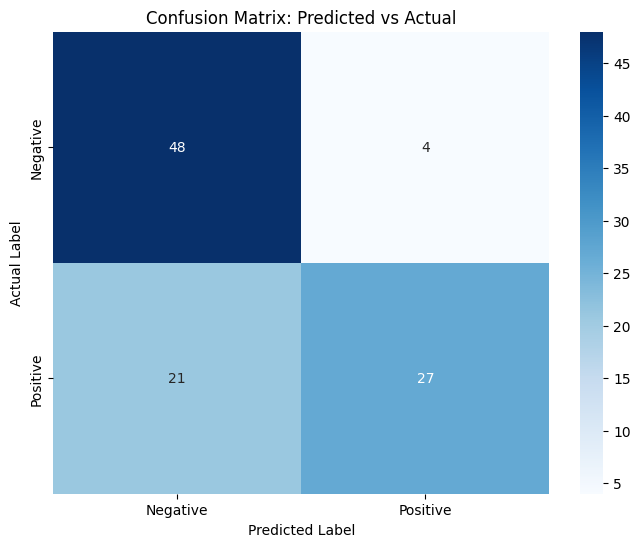


💡 Interpretation: The diagonal (top-left and bottom-right) shows correct predictions.
The off-diagonal squares show where the model made mistakes.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Negative', 'Positive'] # For movie_reviews; use ['Ham', 'Spam'] for spam data

# 2. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

print("\n💡 Interpretation: The diagonal (top-left and bottom-right) shows correct predictions.")
print("The off-diagonal squares show where the model made mistakes.")

**Final "Live" Testing (The Spam/Ham Logic)**

**Metrics:** Accuracy, Precision, Recall, and F1-Score.

**Information:** Evaluated the model's ability to distinguish between "Positive" and "Negative" sentiments. The Confusion Matrix provides a visual representation of the True Positives versus False Positives, highlighting specific areas where the model may struggle with sarcasm or complex phrasing.

In [8]:
def classify_new_review(custom_review):
    # 1. Preprocess the custom input
    cleaned_input = full_preprocess(custom_review)

    # 2. Vectorize using the SAME vectorizer from Step 3
    vec_input = tfidf_vec.transform([cleaned_input])

    # 3. Predict
    prediction = clf.predict(vec_input)[0]

    # 4. Get probability (confidence)
    prob = clf.predict_proba(vec_input).max()

    print(f"Review: \"{custom_review}\"")
    print(f"Classification: {prediction.upper()} | Confidence: {prob:.2%}\n")

# --- Test with your own thoughts ---
print("🔍 --- TESTING CUSTOM INPUTS ---")
classify_new_review("This movie was an absolute masterpiece with great acting!")
classify_new_review("Waste of time. The plot was boring and the script was terrible.")

🔍 --- TESTING CUSTOM INPUTS ---
Review: "This movie was an absolute masterpiece with great acting!"
Classification: POS | Confidence: 57.73%

Review: "Waste of time. The plot was boring and the script was terrible."
Classification: NEG | Confidence: 74.98%

